# Notebook 3: Pemodelan dan Evaluasi Akhir

Selamat datang di tahap paling akhir dari sistem OCR kita. Di sini kita akan merangkai seluruh fitur yang telah diekstrak pada tahap sebelumnya untuk melatih "Otak" utama dari sistem.

Notebook ini bertugas melatih tiga model secara berurutan secara ketat dan kebal kebocoran data: Origin Classifier (penentu negara), Triage Classifier (penentu kualitas), dan Field Classifier (penentu jenis teks). Di akhir notebook, kita akan bisa melihat skor akhir yang menentukan apakah sistem ini siap dipakai di dunia nyata atau belum.

## Inisialisasi dan Impor Modul Dasar
Blok ini bertugas mengimpor semua pustaka eksternal dan menetapkan variabel jalur folder.
Kita mengatur ini di awal agar sisa kode bisa fokus pada logika inti tanpa perlu berulang kali mengatur jalur file dan pengaturan dasar.

In [86]:
import os
import re
import cv2
import json
import warnings
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import Levenshtein as lev
import lightgbm as lgb
import shap
import optuna
from functools import partial
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.titlesize': 13})

DATASET_DIR   = 'dataset'
IMG_DIR       = os.path.join(DATASET_DIR, 'images')
CROPPED_DIR   = os.path.join(DATASET_DIR, 'cropped_images_lib')  # matches NB2 output directory
MASTER_PATH   = os.path.join(DATASET_DIR, 'master_features.csv')
SEGMENTS_PATH = os.path.join(DATASET_DIR, 'ocr_segments_features.csv')
FOLD_PATH     = os.path.join(DATASET_DIR, 'fold_indices.pkl')

FEATURE_COLS = [
    'y_rel_scaled', 'x_rel_scaled', 'width_rel_scaled',
    'text_len', 'word_count',
    'ocr_conf', 'alpha_ratio', 'digit_ratio', 'is_all_caps',
    'has_date_pattern', 'has_address_kw', 'has_state_kw',
    'has_postcode', 'has_bin_binti', 'line_rank_norm',
    'doc_origin_encoded',
]

TRIAGE_FEATURES = [
    'crop_blur_score_log', 'crop_brightness', 'crop_contrast',
    'crop_edge_density', 'crop_dark_pixel_ratio', 'skew_angle', 'quality_pc1',
]

LABEL_MAP     = {'other': 0, 'name': 1, 'birth_date': 2, 'address': 3}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}
COLOR_MAP = {
    'name':       (0,   0, 255),
    'birth_date': (255, 0,   0),
    'address':    (0, 255,   0),
    'other':      (128, 128, 128),
}

print('Setup selesai.')

Setup selesai.


## Memuat Data Utama
Blok ini mengambil data csv dan indeks pembagian pelatihan yang sudah dibuat dari tahap sebelumnya.
Kita menggunakan pembagian data pelatihan yang dikunci di awal supaya pengujian kita adil dan tidak ada data identitas yang bocor.

In [87]:
# --- LOAD DATA ---
print("Loading data...")
df_test = pd.read_csv(MASTER_PATH)

# Bug 10 Fix: master_features.csv might have stale ground truth if ground_truth_normalized.csv was edited manually.
# We merge the fresh ground truth here to ensure evaluation uses the latest corrections.
gt_fresh = pd.read_csv(os.path.join(DATASET_DIR, 'ground_truth_normalized.csv'))
# Drop the stale ground truth columns and merge the fresh ones
df_test = df_test.drop(columns=['name', 'birth_date', 'address', 'negara'], errors='ignore')
df_test = df_test.merge(gt_fresh[['filename', 'name', 'birth_date', 'address', 'negara']], on='filename', how='left')
df = df_test
df_segments = pd.read_csv(SEGMENTS_PATH)

with open(FOLD_PATH, 'rb') as f:
    folds = pickle.load(f)

print(f"Master df     : {len(df)} gambar")
print(f"Segmen        : {len(df_segments)} segmen teks")
print(f"Jumlah fold   : {len(folds)}")

Loading data...
Master df     : 632 gambar
Segmen        : 11405 segmen teks
Jumlah fold   : 5


## Mengatur Fungsi Metrik Evaluasi Teks
Blok ini merumuskan kalkulator akurasi teks seperti CER WER dan Token F1.
Kita memakai rumus matematis ini karena mencocokkan kemiripan tulisan identitas jauh lebih masuk akal ketimbang menuntut akurasi huruf sempurna seratus persen.

In [88]:
def compute_cer(hyp: str, ref: str) -> float:
    ref_str = str(ref).strip().lower()
    hyp_str = str(hyp).strip().lower()
    if len(ref_str) == 0:
        return 0.0 if len(hyp_str) == 0 else 1.0
    return lev.distance(hyp_str, ref_str) / len(ref_str)

def compute_wer(hyp: str, ref: str) -> float:
    ref_words = str(ref).strip().lower().split()
    hyp_words = str(hyp).strip().lower().split()
    if len(ref_words) == 0:
        return 0.0 if len(hyp_words) == 0 else 1.0
    return lev.distance(' '.join(hyp_words), ' '.join(ref_words)) / len(ref_words)

def compute_f1_token(hyp: str, ref: str) -> float:
    ref_set = set(str(ref).strip().lower().split())
    hyp_set = set(str(hyp).strip().lower().split())
    if not ref_set and not hyp_set:
        return 1.0
    if not ref_set or not hyp_set:
        return 0.0
    tp        = len(ref_set & hyp_set)
    precision = tp / len(hyp_set)
    recall    = tp / len(ref_set)
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

def exact_accuracy(hyp: str, ref: str) -> float:
    return float(str(hyp).strip().lower() == str(ref).strip().lower())

## Membersihkan dan Validasi Teks
Blok ini menghapus simbol aneh, singkatan alamat, dan memastikan tanggal lahir masuk akal.
Kita melakukan tahap ini supaya kecacatan kecil pembacaan bisa diperbaiki otomatis sehingga manusia tidak perlu turun tangan.

In [89]:
ADDR_ABBREV = {
    r'\bJLN\b': 'JALAN', r'\bLRG\b': 'LORONG', r'\bKG\b': 'KAMPUNG',
    r'\bTMN\b': 'TAMAN', r'\bPKR\b': 'PERAK',
}

def _normalize_name(text: str) -> str:
    text = text.upper().strip()
    for noise in ['NAMA:', 'NAME:', 'NAMA', 'NAME', 'PENUH', 'FULL']:
        text = text.replace(noise, '')
    text = re.sub(r'[^A-Z /\-]', ' ', text)
    noise_words = ['WARGANEGARA', 'MALAYSIA', 'LELAKI', 'PEREMPUAN', 'ISLAM', 'MYKAD', 'KAD', 'PENGENALAN']
    for noise in noise_words:
        text = re.sub(rf'\b{noise}\b', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def _normalize_date(t: str) -> str:
    if not t or pd.isna(t):
        return ''
    t = str(t).upper().replace(',', '').strip()
    
    # 1. DD.MM.YYYY or DD:MM:YYYY or DD-MM-YYYY
    m = re.search(r'\b(\d{2})[.:/-](\d{2})[.:/-](\d{4})\b', t)
    if m:
        return f"{m.group(3)}-{m.group(2)}-{m.group(1)}"
        
    # 2. YYYY:MM.DD or similar
    m = re.search(r'\b(\d{4})[.:/-](\d{2})[.:/-](\d{2})\b', t)
    if m:
        return f"{m.group(1)}-{m.group(2)}-{m.group(3)}"
        
    # 3. DD MONTH YYYY
    months = {
        'JAN': '01', 'JANUARI': '01', 'JANUARY': '01',
        'FEB': '02', 'FEBRUARI': '02', 'FEBRUARY': '02',
        'MAR': '03', 'MAC': '03', 'MARCH': '03', 'MARET': '03',
        'APR': '04', 'APRIL': '04',
        'MAY': '05', 'MEI': '05',
        'JUN': '06', 'JUNE': '06', 'JUNI': '06',
        'JUL': '07', 'JULY': '07', 'JULI': '07',
        'AUG': '08', 'OGOS': '08', 'AUGUST': '08', 'AGUSTUS': '08',
        'SEP': '09', 'SEPTEMBER': '09',
        'OCT': '10', 'OKT': '10', 'OKTOBER': '10', 'OCTOBER': '10',
        'NOV': '11', 'NOVEMBER': '11',
        'DEC': '12', 'DIS': '12', 'DISEMBER': '12', 'DECEMBER': '12', 'DESEMBER': '12'
    }
    for mon_str, mon_num in months.items():
        if mon_str in t:
            m = re.search(r'(\d{1,2})\s+' + mon_str + r'\s+(\d{4})', t)
            if m:
                dd = m.group(1).zfill(2)
                return f"{m.group(2)}-{mon_num}-{dd}"
                
    # 4. Fallback to MRZ/IC matching
    text_clean = re.sub(r'[^0-9A-Z<]', '', t)
    m_mrz = re.search(r'[A-Z<]{3}(\d{2})(\d{2})(\d{2})\d[A-Z<]', text_clean)
    if m_mrz:
        yy, mm, dd = m_mrz.groups()
        if 1 <= int(mm) <= 12 and 1 <= int(dd) <= 31:
            yyyy = "19" + yy if int(yy) > 25 else "20" + yy
            return f"{yyyy}-{mm}-{dd}"

    m_ic = re.search(r'(\d{2})(\d{2})(\d{2})\d{2}\d{4}', text_clean)
    if m_ic:
        yy, mm, dd = m_ic.groups()
        if 1 <= int(mm) <= 12 and 1 <= int(dd) <= 31:
            yyyy = "19" + yy if int(yy) > 25 else "20" + yy
            return f"{yyyy}-{mm}-{dd}"
            
    # 5. Generic YYMMDD fallback (only if length is 6 exactly to avoid mangling DD.MM.YYYY)
    if len(text_clean) == 6 and text_clean.isdigit():
        yy, mm, dd = text_clean[0:2], text_clean[2:4], text_clean[4:6]
        if 1 <= int(mm) <= 12 and 1 <= int(dd) <= 31:
            yyyy = "19" + yy if int(yy) > 25 else "20" + yy
            return f"{yyyy}-{mm}-{dd}"

    return str(t).strip()

def _normalize_address(text: str) -> str:
    text = text.upper().strip()
    for noise in ['ALAMAT:', 'ADDRESS:', 'ALAMAT', 'ADDRESS']:
        text = text.replace(noise, '')
    for abbr, full in ADDR_ABBREV.items():
        text = re.sub(abbr, full, text)
    return re.sub(r'\s+', ' ', text).strip()

def validate_name(text: str) -> tuple:
    if not text or len(text) < 2:
        return False, 'EMPTY'
    if any(c.isdigit() for c in text):
        return False, 'CONTAINS_DIGIT'
    if len(text) > 100:
        return False, 'TOO_LONG'
    return True, 'OK'

def validate_date(text: str) -> tuple:
    if not text:
        return False, 'EMPTY'
    m = re.match(r'^(\d{4})(?:-(\d{2})-(\d{2}))?$', text)
    if not m:
        return False, 'BAD_FORMAT'
    year = int(m.group(1))
    if not (1900 <= year <= 2015):
        return False, f'YEAR_OUT_OF_RANGE:{year}'
    if m.group(2):
        month, day = int(m.group(2)), int(m.group(3))
        if not (1 <= month <= 12):
            return False, f'BAD_MONTH:{month}'
        if not (1 <= day <= 31):
            return False, f'BAD_DAY:{day}'
    return True, 'OK'

# --- TEMPLATE ROUTER ARCHITECTURE ---

def detect_template(segs_df: pd.DataFrame) -> str:
    texts = segs_df['text'].dropna().astype(str).tolist()
    all_text = ' '.join(texts).upper()

    # 1. MRZ — fixed-width line, heavy '<' density, near bottom of card
    mrz_pattern = re.compile(r'^[A-Z0-9<]{28,44}$')
    for t in texts:
        t_clean = t.replace(' ', '').upper()
        if mrz_pattern.match(t_clean) and t_clean.count('<') >= 5:
            return 'mrz'

    # 2. EU/EEA numbered driving licence — "1.", "2.", "3." prefixes
    numbered = re.compile(r'^\d[a-c]?\.\s*\S')
    n_numbered_hits = sum(1 for t in texts if numbered.match(t.strip()))
    if n_numbered_hits >= 3:
        return 'eu_license'

    # 3. EU-style citizen/ID card family — e.g. "1.68 PRT"
    if re.search(r'\b\d\.\d{2}\s+[A-Z]{3}\b', all_text):
        return 'eu_id_positional'

    # 4. MyKad
    if any(kw in all_text for kw in ['MYKAD', 'KAD PENGENALAN', 'WARGANEGARA']):
        return 'mykad'

    # Bugs 2+6 fix: Keys now contain only the clean country name (no 'fallback_' prefix).
    # return f'fallback_{clean_country}' below will produce the correct single-prefix string.
    # Double-underscore keys (e.g. 'fallback__CAMBODIA') also removed.
    # Dataset-relevant countries expanded with native-language names.
    # ISO 3-letter codes removed — they are substrings of other words and cause false matches.
    # Key names must match the 'negara' ground-truth values exactly (same casing, underscores=spaces).
    COUNTRY_ALIASES = {
        # --- Asia-Pacific ---
        'CAMBODIA':         ['CAMBODIA'],
        'CHINA':            ['CHINA', 'ZHONGGUO'],
        'HONG_KONG':        ['HONG KONG'],
        'JAPAN':            ['JAPAN', 'NIHON', 'NIPPON'],
        'MACAU':            ['MACAU', 'MACAO'],
        'MONGOLIA':         ['MONGOLIA'],
        'NORTH_KOREA':      ['NORTH KOREA'],
        'SOUTH_KOREA':      ['SOUTH KOREA'],
        'TAIWAN':           ['TAIWAN'],
        'VIETNAM':          ['VIETNAM', 'VIET NAM'],
        # --- Europe (dataset countries expanded) ---
        'HUNGARY':          ['HUNGARY', 'MAGYARORSZAG'],
        'ALBANIA':          ['ALBANIA'],
        'ANDORRA':          ['ANDORRA'],
        'ARMENIA':          ['ARMENIA'],
        'AUSTRIA':          ['AUSTRIA', 'OSTERREICH'],
        'AZERBAIJAN':       ['AZERBAIJAN'],
        'BELARUS':          ['BELARUS'],
        'BELGIUM':          ['BELGIUM', 'BELGIQUE', 'BELGIE'],
        'BOSNIA_AND_HERZEGOVINA': ['BOSNIA', 'HERZEGOVINA'],
        'BULGARIA':         ['BULGARIA'],
        'CROATIA':          ['CROATIA', 'HRVATSKA'],       # dataset: 40 images
        'CYPRUS':           ['CYPRUS'],
        'CZECH REPUBLIC':   ['CZECH REPUBLIC', 'CZECHIA', 'CESKA REPUBLIKA'],  # dataset: 40 images; key matches negara
        'DENMARK':          ['DENMARK', 'DANMARK'],
        'ESTONIA':          ['ESTONIA', 'EESTI'],
        'FINLAND':          ['FINLAND', 'SUOMI'],          # dataset: 40 images
        'FRANCE':           ['FRANCE'],
        'GEORGIA':          ['GEORGIA'],
        'GERMANY':          ['GERMANY', 'DEUTSCHLAND'],    # dataset: 60 images
        'GREECE':           ['GREECE', 'HELLAS', 'HELLENIC'],  # dataset: 20 images
        'IRELAND':          ['IRELAND'],
        'ITALY':            ['ITALY', 'ITALIA'],           # dataset: 20 images
        'KAZAKHSTAN':       ['KAZAKHSTAN'],
        'KOSOVO':           ['KOSOVO'],
        'LATVIA':           ['LATVIA', 'LATVIJA'],         # dataset: 20 images
        'LIECHTENSTEIN':    ['LIECHTENSTEIN'],
        'LITHUANIA':        ['LITHUANIA', 'LIETUVA'],
        'LUXEMBOURG':       ['LUXEMBOURG'],
        'MALTA':            ['MALTA'],
        'MOLDOVA':          ['MOLDOVA', 'REPUBLICA MOLDOVA'],  # dataset: 20 images
        'MONACO':           ['MONACO'],
        'MONTENEGRO':       ['MONTENEGRO'],
        'NETHERLANDS':      ['NETHERLANDS', 'NEDERLAND'],
        'NORTH_MACEDONIA':  ['NORTH MACEDONIA'],
        'NORWAY':           ['NORWAY', 'NORGE'],           # dataset: 20 images
        'POLAND':           ['POLAND', 'POLSKA'],          # dataset: 20 images
        'PORTUGAL':         ['PORTUGAL'],                  # dataset: 20 images
        'ROMANIA':          ['ROMANIA'],
        'RUSSIA':           ['RUSSIA'],
        'SAN_MARINO':       ['SAN MARINO'],
        'SERBIA':           ['SERBIA'],
        'SLOVAKIA':         ['SLOVAKIA', 'SLOVENSKO'],
        'SLOVENIA':         ['SLOVENIA', 'SLOVENIJA'],
        'SPAIN':            ['SPAIN', 'ESPANA', 'REINO DE ESPANA'],  # dataset: 20 images
        'SWEDEN':           ['SWEDEN', 'SVERIGE'],
        'SWITZERLAND':      ['SWITZERLAND', 'SCHWEIZ', 'SUISSE'],
        'TURKEY':           ['TURKEY', 'TURKIYE'],         # dataset: 20 images
        'UKRAINE':          ['UKRAINE'],                   # dataset: 40 images
        'UNITED_KINGDOM':   ['UNITED KINGDOM'],
        'VATICAN_CITY':     ['VATICAN CITY'],
        # --- Americas (dataset countries expanded) ---
        'ARGENTINA':        ['ARGENTINA', 'ARG'],
        'BAHAMAS':          ['BAHAMAS', 'BHS'],
        'BARBADOS':         ['BARBADOS', 'BRB'],
        'BELIZE':           ['BELIZE', 'BLZ'],
        'BOLIVIA':          ['BOLIVIA', 'BOL'],
        'BRAZIL':           ['BRAZIL', 'BRASIL', 'BRA'],  # dataset: 20 images
        'CHILE':            ['CHILE', 'CHL'],  # dataset: 20 images
        'COLOMBIA':         ['COLOMBIA', 'COL'],
        'COSTA_RICA':       ['COSTA RICA', 'CRI'],
        'CUBA':             ['CUBA', 'CUB'],
        'DOMINICA':         ['DOMINICA', 'DMA'],
        'DOMINICAN_REPUBLIC': ['DOMINICAN REPUBLIC', 'REPUBLICA DOMINICANA', 'DOM'],
        'ECUADOR':          ['ECUADOR', 'ECU'],
        'EL_SALVADOR':      ['EL SALVADOR', 'SLV'],
        'GRENADA':          ['GRENADA', 'GRD'],
        'GUATEMALA':        ['GUATEMALA', 'GTM'],
        'GUYANA':           ['GUYANA', 'GUY'],
        'HAITI':            ['HAITI', 'HTI'],
        'HONDURAS':         ['HONDURAS', 'HND'],
        'JAMAICA':          ['JAMAICA', 'JAM'],
        'MEXICO':           ['MEXICO', 'MEX'],
        'NICARAGUA':        ['NICARAGUA', 'NIC'],
        'PANAMA':           ['PANAMA', 'PAN'],
        'PARAGUAY':         ['PARAGUAY', 'PRY'],
        'PERU':             ['PERU', 'PER'],
        'ST_KITTS_AND_NEVIS': ['ST. KITTS', 'NEVIS', 'KNA'],
        'ST_LUCIA':         ['ST. LUCIA', 'LCA'],
        'ST_VINCENT_AND_THE_GRENADINES': ['ST. VINCENT', 'THE GRENADINES', 'VCT'],
        'SURINAME':         ['SURINAME', 'SUR'],
        'TRINIDAD_AND_TOBAGO': ['TRINIDAD', 'TOBAGO', 'TTO'],
        'URUGUAY':          ['URUGUAY', 'URY'],
        'VENEZUELA':        ['VENEZUELA', 'VEN'],
        # --- Africa (dataset countries expanded) ---
        'ALGERIA':          ['ALGERIA', 'ALGERIE', 'DZA'],  # dataset: 20 images
        'ANGOLA':           ['ANGOLA', 'AGO'],
        'BENIN':            ['BENIN', 'BEN'],
        'BURKINA_FASO':     ['BURKINA FASO', 'BFA'],
        'BURUNDI':          ['BURUNDI', 'BDI'],
        'CABO_VERDE':       ['CABO VERDE', 'CAPE VERDE', 'CPV'],
        'CAMEROON':         ['CAMEROON', 'CMR'],
        'CENTRAL_AFRICAN_REPUBLIC': ['CENTRAL AFRICAN REPUBLIC', 'CAF'],
        'CHAD':             ['CHAD', 'TCD'],
        'COMOROS':          ['COMOROS', 'COM'],
        'DR_CONGO':         ['DR CONGO', 'COD'],
        'REPUBLIC_OF_THE_CONGO': ['REPUBLIC OF THE CONGO', 'COG'],
        'DJIBOUTI':         ['DJIBOUTI', 'DJI'],
        'EQUATORIAL_GUINEA': ['EQUATORIAL GUINEA', 'GNQ'],
        'GABON':            ['GABON', 'GAB'],
        'GUINEA':           ['GUINEA', 'GIN'],
        'GUINEA_BISSAU':    ['GUINEA-BISSAU', 'GNB'],
        'IVORY_COAST':      ['IVORY COAST', 'COTE D IVOIRE', 'CIV'],
        'MADAGASCAR':       ['MADAGASCAR', 'MDG'],
        'MALI':             ['MALI', 'MLI'],
        'MAURITANIA':       ['MAURITANIA', 'MRT'],
        'MAURITIUS':        ['MAURITIUS', 'MUS'],
        'MOROCCO':          ['MOROCCO', 'MAROC', 'MAR'],
        'MOZAMBIQUE':       ['MOZAMBIQUE', 'MOZ'],
        'NIGER':            ['NIGER', 'NER'],
        'RWANDA':           ['RWANDA', 'RWA'],
        'SAO_TOME_AND_PRINCIPE': ['SAO TOME', 'PRINCIPE', 'STP'],
        'SENEGAL':          ['SENEGAL', 'SEN'],
        'SEYCHELLES':       ['SEYCHELLES', 'SYC'],
        'TOGO':             ['TOGO', 'TGO'],
        'TUNISIA':          ['TUNISIA', 'TUNISIE', 'TUN'],
        # --- Pacific ---
        'FIJI':             ['FIJI', 'FJI'],
        'KIRIBATI':         ['KIRIBATI', 'KIR'],
        'MARSHALL_ISLANDS': ['MARSHALL ISLANDS', 'MHL'],
        'MICRONESIA':       ['MICRONESIA', 'FSM'],
        'NAURU':            ['NAURU', 'NRU'],
        'PALAU':            ['PALAU', 'PLW'],
        'PAPUA_NEW_GUINEA': ['PAPUA NEW GUINEA', 'PNG'],
        'SAMOA':            ['SAMOA', 'WSM'],
        'SOLOMON_ISLANDS':  ['SOLOMON ISLANDS', 'SLB'],
        'TONGA':            ['TONGA', 'TON'],
        'TUVALU':           ['TUVALU', 'TUV'],
        'VANUATU':          ['VANUATU', 'VUT'],
        # --- Other ---
        'AUSTRALIA':        ['AUSTRALIA', 'AUS'],
        'CANADA':           ['CANADA', 'CAN'],
        'NEW_ZEALAND':      ['NEW ZEALAND', 'NZL'],
        'PHILIPPINES':      ['PHILIPPINES', 'PHL'],
        'UNITED_STATES':    ['UNITED STATES', 'USA'],
        'BAHRAIN':          ['BAHRAIN', 'BHR'],
        'EGYPT':            ['EGYPT', 'EGY'],
        'IRAQ':             ['IRAQ', 'IRQ'],
        'JORDAN':           ['JORDAN', 'JOR'],
        'KUWAIT':           ['KUWAIT', 'KWT'],
        'LEBANON':          ['LEBANON', 'LBN'],
        'LIBYA':            ['LIBYA', 'LBY'],
        'OMAN':             ['OMAN', 'OMN'],
        'QATAR':            ['QATAR', 'QAT'],
        'SAUDI_ARABIA':     ['SAUDI ARABIA', 'SAU'],
        'SYRIA':            ['SYRIA', 'SYR'],
        'UAE':              ['UAE', 'UNITED ARAB EMIRATES', 'ARE'],
        'YEMEN':            ['YEMEN', 'YEM'],
        'AFGHANISTAN':      ['AFGHANISTAN', 'AFG'],
        'BANGLADESH':       ['BANGLADESH', 'BGD'],
        'BHUTAN':           ['BHUTAN', 'BTN'],
        'BRUNEI':           ['BRUNEI', 'BRN'],
        'ERITREA':          ['ERITREA', 'ERI'],
        'ETHIOPIA':         ['ETHIOPIA', 'ETH'],
        'ICELAND':          ['ICELAND', 'ISLAND', 'ISL'],
        'INDIA':            ['INDIA', 'IND'],
        'INDONESIA':        ['INDONESIA', 'IDN'],
        'MALAYSIA':         ['MALAYSIA', 'MYS'],
        'MALDIVES':         ['MALDIVES', 'MDV'],
        'MYANMAR':          ['MYANMAR', 'MMR'],
        'NEPAL':            ['NEPAL', 'NPL'],
        'PAKISTAN':         ['PAKISTAN', 'PAK'],
        'SINGAPORE':        ['SINGAPORE', 'SGP'],
        'SOMALIA':          ['SOMALIA', 'SOM'],
        'SOUTH_SUDAN':      ['SOUTH SUDAN', 'SSD'],
        'SRI_LANKA':        ['SRI LANKA', 'LKA'],
        'SUDAN':            ['SUDAN', 'SDN'],
    }
    # IMPORTANT: use whole-word regex matching, NOT substring 'in'.
    # Short aliases (e.g. 'KOR', 'AND', 'ARM') match inside other words:
    #   'KOR' in 'HENKILOKORTTI' (Finnish for 'identity card') = True  → Finnish cards → SOUTH_KOREA
    #   'AND' in 'RHEINLAND' (German region) = True                   → German cards  → ANDORRA
    #   'ARM' in 'ARMAS' (Spanish word) = True                        → Spanish cards → ARMENIA
    # Rule: aliases shorter than 5 chars must NOT be in this dict.
    _alias_re_cache = {}
    def _country_match(alias, text):
        if alias not in _alias_re_cache:
            _alias_re_cache[alias] = re.compile(r'\b' + re.escape(alias) + r'\b')
        return bool(_alias_re_cache[alias].search(text))

    for clean_country, aliases in COUNTRY_ALIASES.items():
        if any(_country_match(alias, all_text) for alias in aliases):
            return f'fallback_{clean_country}'

    return 'unknown'


def extract_mrz(segs_df: pd.DataFrame) -> tuple:
    segs_sorted = segs_df.sort_values('y_rel')
    texts = segs_sorted['text'].dropna().astype(str).tolist()
    
    def is_mrz(t):
        t = str(t).replace(' ', '').upper()
        return bool(re.match(r'^[A-Z0-9<]{28,44}$', t)) and t.count('<') >= 5
    
    mrz_df = segs_sorted[segs_sorted['text'].apply(is_mrz)]
    if mrz_df.empty:
        return '', 0.0, '', 0.0, '', 0.0

    name_line, name_conf = None, 0.0
    dob_line, dob_conf = None, 0.0
    
    if len(mrz_df) == 2:
        name_line = str(mrz_df.iloc[0]['text']).replace(' ', '').upper()
        name_conf = float(mrz_df.iloc[0]['ocr_conf']) if pd.notna(mrz_df.iloc[0]['ocr_conf']) else 0.0
        dob_line = str(mrz_df.iloc[1]['text']).replace(' ', '').upper()
        dob_conf = float(mrz_df.iloc[1]['ocr_conf']) if pd.notna(mrz_df.iloc[1]['ocr_conf']) else 0.0
    elif len(mrz_df) >= 3:
        name_line = str(mrz_df.iloc[2]['text']).replace(' ', '').upper()
        name_conf = float(mrz_df.iloc[2]['ocr_conf']) if pd.notna(mrz_df.iloc[2]['ocr_conf']) else 0.0
        dob_line = str(mrz_df.iloc[1]['text']).replace(' ', '').upper()
        dob_conf = float(mrz_df.iloc[1]['ocr_conf']) if pd.notna(mrz_df.iloc[1]['ocr_conf']) else 0.0
    elif len(mrz_df) == 1:
        row = mrz_df.iloc[0]
        l = str(row['text']).replace(' ', '').upper()
        conf = float(row['ocr_conf']) if pd.notna(row['ocr_conf']) else 0.0
        if bool(re.search(r'\d{6}', l)):
            dob_line, dob_conf = l, conf
        else:
            name_line, name_conf = l, conf

    name = ''
    if name_line:
        # Strip leading document-type prefix (e.g. 'P<GBR') before the name zone
        name_zone = name_line
        if '<<' in name_line:
            # Find first '<<' which separates surname from given names
            # Name zone starts after the first 5-char type+country prefix
            content = name_line[5:] if len(name_line) > 5 else name_line
            parts = content.split('<<', 1)
            if len(parts) == 2:
                surname = parts[0].replace('<', ' ').strip()
                given   = parts[1].split('<<<<')[0].replace('<', ' ').strip()
                name    = f"{given} {surname}" if given else surname
            else:
                name = content.replace('<', ' ').strip()

    dob = ''
    if dob_line:
        yymmdd = ''
        if len(dob_line) >= 19 and dob_line[13:19].isdigit():
            yymmdd = dob_line[13:19]  # TD3 Passport (e.g. AA000000<0BRA8101109...)
        elif len(dob_line) >= 6 and dob_line[0:6].isdigit():
            yymmdd = dob_line[0:6]    # TD1 ID Card
        else:
            m = re.search(r'(?<!\d)(\d{6})(?!\d)', dob_line)
            if m: yymmdd = m.group(1)
            
        if yymmdd.isdigit() and len(yymmdd) == 6:
            prefix = '19' if int(yymmdd[0:2]) > 26 else '20'
            dob = f"{prefix}{yymmdd[0:2]}-{yymmdd[2:4]}-{yymmdd[4:6]}"

    return name, name_conf, dob, dob_conf, '', 0.0

def extract_eu_license(segs_df: pd.DataFrame) -> tuple:
    fields = {}
    confs = {}
    for _, row in segs_df.dropna(subset=['text']).iterrows():
        t = str(row['text'])
        # Bug 4a fix: dot after field number is optional in OCR output (e.g. "2 Anne" not "2. Anne").
        # \s+ (one or more spaces) prevents false matches on bare digits.
        m = re.match(r'^(\d[a-c]?)\.?\s+(.*)', t.strip())
        if m:
            key = m.group(1)
            fields[key] = m.group(2).strip()
            confs[key] = float(row['ocr_conf']) if pd.notna(row['ocr_conf']) else 0.0

    # Bug 4c fix: OCR sometimes fuses field number into DOB value (e.g. "328.02.64" = field 3 + "28.02.64").
    if '3' not in fields:
        for _, row in segs_df.dropna(subset=['text']).iterrows():
            t = str(row['text'])
            m_fused = re.match(r'^\d(\d{2}[.:/-]\d{2}[.:/-]\d{2,4})$', t.strip().replace(' ', ''))
            if m_fused:
                fields['3'] = m_fused.group(1)
                confs['3'] = float(row['ocr_conf']) if pd.notna(row['ocr_conf']) else 0.0
                break

    surname = fields.get('1', '').strip()
    given   = fields.get('2', '').strip()
    
    name_conf_vals = [confs[k] for k in ['1', '2'] if k in confs]
    name_conf = sum(name_conf_vals) / len(name_conf_vals) if name_conf_vals else 0.0

    # Bug 4a fix (continued): don't silently collapse to surname-only when given name is missing.
    if given and surname:
        name = f"{given} {surname}"
    elif surname:
        name = surname
    else:
        name = given

    dob_raw = fields.get('3', '')
    dob = _normalize_date(dob_raw)
    dob_conf = confs.get('3', 0.0)

    return name, name_conf, dob, dob_conf, '', 0.0

def extract_mykad(segs_df: pd.DataFrame) -> tuple:
    name, name_conf = _assemble_field(segs_df, 'name', True)
    dob, dob_conf  = _assemble_field(segs_df, 'birth_date', True)
    addr, addr_conf = _assemble_field(segs_df, 'address', True)
    return name, name_conf, dob, dob_conf, addr, addr_conf

# Bug 5: Field label words to strip from name segments for foreign ID cards.
# These are printed field headers that the ML classifier may label as 'name' if they appear on the same line.
_FIELD_LABEL_WORDS = {
    'NOMBRES', 'APELLIDOS', 'NOMBRE', 'APELLIDO',         # Spanish
    'NOM', 'PRENOM', 'PRÉNOM', 'PRENOMS',                  # French
    'COGNOME', 'NOME',                                      # Italian
    'SOBRENOME', 'NOME COMPLETO',                           # Portuguese
    'FAMILIENNAME', 'VORNAME', 'NACHNAME',                  # German
    'IMIE', 'NAZWISKO',                                     # Polish
    'IME', 'PREZIME',                                       # Croatian/Serbian
    'CHILENA', 'CHILENO', 'BRASILEIRA', 'BRASILEIRO',       # Nationality adjectives
    'ALGERIEN', 'ALGERIENNE',                               # French nationality adjectives
}

def extract_fallback_country(segs_df: pd.DataFrame, country: str) -> tuple:
    name, name_conf = _assemble_field(segs_df, 'name', False)

    # Bug 5 fix: strip known field label words before returning name.
    if name:
        name_tokens = name.upper().split()
        name_tokens = [tok for tok in name_tokens if tok not in _FIELD_LABEL_WORDS]
        # Also strip colon-suffixed labels (e.g. 'APELLIDOS:' → removed)
        name_tokens = [tok for tok in name_tokens if tok.rstrip(':') not in _FIELD_LABEL_WORDS]
        name = ' '.join(name_tokens).strip()

    # country string is already clean (e.g. 'GERMANY') after the detect_template fix.
    c_clean = country.replace('_', '').upper()
    surname_first_countries = {
        'CAMBODIA', 'CHINA', 'HONGKONG', 'JAPAN', 'MACAU', 'MONGOLIA',
        'NORTHKOREA', 'SOUTHKOREA', 'TAIWAN', 'VIETNAM',
        'HUNGARY', 'ALBANIA', 'ANDORRA', 'ARMENIA', 'AUSTRIA', 'AZERBAIJAN',
        'BELARUS', 'BELGIUM', 'BOSNIAANDHERZEGOVINA', 'BULGARIA', 'CROATIA',
        'CYPRUS', 'CZECHIA', 'CZECHREPUBLIC', 'DENMARK', 'ESTONIA', 'FINLAND',
        'FRANCE', 'GEORGIA', 'GERMANY', 'GREECE', 'IRELAND', 'ITALY',
        'KAZAKHSTAN', 'KOSOVO', 'LATVIA', 'LIECHTENSTEIN', 'LITHUANIA',
        'LUXEMBOURG', 'MALTA', 'MOLDOVA', 'MONACO', 'MONTENEGRO',
        'NETHERLANDS', 'NORTHMACEDONIA', 'NORWAY', 'POLAND', 'PORTUGAL',
        'ROMANIA', 'RUSSIA', 'SANMARINO', 'SERBIA', 'SLOVAKIA', 'SLOVENIA',
        'SPAIN', 'SWEDEN', 'SWITZERLAND', 'TURKEY', 'UKRAINE', 'UNITEDKINGDOM',
        'VATICANCITY', 'ARGENTINA', 'BAHAMAS', 'BARBADOS', 'BELIZE', 'BOLIVIA',
        'CHILE', 'COLOMBIA', 'COSTARICA', 'CUBA', 'DOMINICA', 'DOMINICANREPUBLIC',
        'ECUADOR', 'ELSALVADOR', 'GRENADA', 'GUATEMALA', 'GUYANA', 'HAITI',
        'HONDURAS', 'JAMAICA', 'MEXICO', 'NICARAGUA', 'PANAMA', 'PARAGUAY',
        'PERU', 'SURINAME', 'TRINIDAD', 'URUGUAY', 'VENEZUELA',
        'ALGERIA', 'ANGOLA', 'BENIN', 'BURKINAFASO', 'BURUNDI', 'CABOVERDE',
        'CAMEROON', 'CHAD', 'COMOROS', 'GABON', 'GUINEA', 'IVORYCOAST',
        'MADAGASCAR', 'MALI', 'MAURITANIA', 'MAURITIUS', 'MOROCCO', 'MOZAMBIQUE',
        'NIGER', 'RWANDA', 'SENEGAL', 'SEYCHELLES', 'TOGO', 'TUNISIA',
    }

    is_surname_first = c_clean in surname_first_countries

    if is_surname_first and name and ' ' in name:
        parts = name.split()
        if len(parts) >= 2:
            # Bug 4b fix: last token is given name, everything before is (compound) surname.
            given   = parts[-1]
            surname = ' '.join(parts[:-1])
            name    = f"{given} {surname}"

    dob, dob_conf = _assemble_field(segs_df, 'birth_date', False)
    return name, name_conf, dob, dob_conf, '', 0.0



def clean_name_pred(text: str) -> str:
    """Removes digits and stray punctuation from name predictions.
    Arabic digits in names are always OCR errors or misclassified ID number fields.
    If an ID number was extracted as a name, stripping digits turns it into an empty string,
    which correctly routes to HUMAN_REVIEW.
    """
    if not text: return ''
    text = re.sub(r'\d+', '', text)
    return text.strip(' -.,;')

# Bug 1 fix: renamed from 'assemble_field' to '_assemble_field' (private helper).
# Public entry-point is extract_fields() below.
def _assemble_field(segs_df: pd.DataFrame, label: str, is_malaysia: bool) -> tuple:
    subset = segs_df[segs_df['pred_label_str'] == label].copy()
    if subset.empty:
        return '', 0.0

    # Drop low-confidence segments to filter out signatures, watermarks, and OCR noise.
    subset = subset[subset['ocr_conf'] >= CONF_FLOOR]  # Bug 8: CONF_FLOOR lowered to 0.70 below
    if subset.empty:
        return '', 0.0

    # Deduplicate overlapping bounding boxes: same word shouldn't be concatenated twice.
    subset = subset.copy()
    subset['_y_rounded'] = subset['y_rel_scaled'].round(2)
    subset['_x_rounded'] = subset['x_rel_scaled'].round(2)
    subset = subset.drop_duplicates(subset=['_y_rounded', '_x_rounded'])
    subset = subset.drop(columns=['_y_rounded', '_x_rounded'])

    avg_conf = float(subset['ocr_conf'].mean())

    # Issue 3: MRZ Deduplication - if predicting DOB, pick lowest y_rel (highest up) to avoid MRZ at bottom
    if label == 'birth_date':
        subset = subset.sort_values('y_rel')
        best_row = subset.iloc[0]
        return _normalize_date(str(best_row['text'])), float(best_row['ocr_conf'])

    if label in ['name', 'address']:
        subset = subset.sort_values('y_rel_scaled')
        line_ids = []
        current_line_id = 0
        last_y = -100
        for y in subset['y_rel_scaled']:
            if y - last_y > 0.02:
                current_line_id += 1
                last_y = y
            line_ids.append(current_line_id)
        subset['line_id'] = line_ids
        subset = subset.sort_values(['line_id', 'x_rel_scaled'])
        
        if label == 'name':
            return _normalize_name(' '.join(subset['text'].astype(str))), avg_conf
        else:
            if not is_malaysia:
                return '', 0.0
            return _normalize_address(' '.join(subset['text'].astype(str))), avg_conf

    return '', 0.0

# Bug 1 fix: renamed from assemble_field_v2 to extract_fields — this is the public entry-point.
def extract_fields(segs_df: pd.DataFrame, is_malaysia: bool) -> tuple:
    template = detect_template(segs_df)

    if template == 'mrz':
        name, name_conf, dob, dob_conf, addr, addr_conf = extract_mrz(segs_df)
    elif template == 'eu_license':
        name, name_conf, dob, dob_conf, addr, addr_conf = extract_eu_license(segs_df)
    elif template == 'mykad':
        name, name_conf, dob, dob_conf, addr, addr_conf = extract_mykad(segs_df)
    elif template.startswith('fallback_'):
        country = template.replace('fallback_', '')
        name, name_conf, dob, dob_conf, addr, addr_conf = extract_fallback_country(segs_df, country)
    else:
        # unknown / eu_id_positional
        name, name_conf = _assemble_field(segs_df, 'name', is_malaysia)
        dob, dob_conf  = _assemble_field(segs_df, 'birth_date', is_malaysia)
        addr, addr_conf = _assemble_field(segs_df, 'address', is_malaysia)

    # Robust Fallback: If DOB is still empty (ML model missed it), scan all segments for a valid date
    if not dob:
        for _, row in segs_df.dropna(subset=['text']).iterrows():
            t = str(row['text'])
            norm = _normalize_date(t)
            if norm and re.match(r'^\d{4}-\d{2}-\d{2}$', norm):
                dob = norm
                dob_conf = float(row['ocr_conf']) if pd.notna(row['ocr_conf']) else 0.5
                break

    name = clean_name_pred(name)
    return name, name_conf, dob, dob_conf, addr, addr_conf

CONF_AUTO_APPROVE = 0.75
CONF_HUMAN_REVIEW = 0.45
# Bug 8 fix: CONF_FLOOR lowered from 0.85 to 0.70.
# PaddleOCR routinely scores foreign-language segments at 0.75-0.85 even when correct.
# The triage gate (blur_score < 30) already rejects genuinely unreadable images upstream.
CONF_FLOOR        = 0.70

def route_decision(pred_name, pred_dob, pred_addr, is_malaysia, triage_feats, triage_clf, crop_blur_score, crop_brightness, crop_dark_pixel_ratio, conf_name, conf_dob, conf_addr):
    # Hard rule: reject if too blurry, too dark, or mostly dark pixels
    if crop_blur_score < 30 or crop_brightness < 30 or crop_dark_pixel_ratio > 0.80:
        return 'REJECT'
        
    name_valid, _ = validate_name(pred_name)
    dob_valid,  _ = validate_date(pred_dob)

    if not name_valid or not dob_valid:
        return 'HUMAN_REVIEW'
        
    # Classifier decision
    if triage_feats is not None and triage_clf is not None:
        triage_pred = triage_clf.predict(triage_feats)[0]
        if triage_pred == 0:
            return 'REJECT'

    min_conf = min(conf_name, conf_dob)
    if is_malaysia:
        min_conf = min(min_conf, conf_addr)
    if min_conf >= CONF_AUTO_APPROVE:
        return 'AUTO_APPROVE'
    return 'HUMAN_REVIEW'

## Melatih Model dan Mengukur Akurasi
Blok ini melatih detektor negara, pengukur buram, serta penentu kategori teks secara ketat dan terpisah untuk setiap bagian data pelatihan.
Kita memakai skema Cross Validation supaya akurasi yang tercatat benar benar mencerminkan kemampuannya saat dihadapkan pada KTP baru di dunia nyata yang belum pernah ia temui.

In [90]:
all_fold_metrics = []
origin_clf_metrics = []
triage_metrics = []
# Declared outside the fold loop so all 632 images accumulate.
# Each image appears in exactly one test fold, so there are no duplicates.
all_predictions_log = []

for fold_idx, fold_dict in enumerate(folds):
    train_idx, test_idx = fold_dict['train'], fold_dict['test']
    print(f"\n{'='*55}")
    print(f"FOLD {fold_idx + 1} / {len(folds)}")
    
    df_train = df.iloc[train_idx].copy()
    df_test  = df.iloc[test_idx].copy()

    train_filenames = set(df_train['filename'])
    test_filenames  = set(df_test['filename'])

    df_seg_train = df_segments[df_segments['filename'].isin(train_filenames)].copy()
    df_seg_test  = df_segments[df_segments['filename'].isin(test_filenames)].copy()

    train_texts = df_seg_train.groupby('filename')['text'].apply(lambda x: ' '.join([str(v).lower() for v in x]))
    y_origin_train = df_train.set_index('filename').loc[train_texts.index, 'doc_origin_encoded_target'] == 1
    
    origin_clf = make_pipeline(TfidfVectorizer(max_features=300), LogisticRegression(random_state=42, class_weight='balanced'))
    origin_clf.fit(train_texts, y_origin_train)
    
    train_origin_preds = origin_clf.predict(train_texts)
    origin_pred_dict_train = dict(zip(train_texts.index, train_origin_preds))
    df_seg_train['doc_origin_encoded'] = df_seg_train['filename'].map(origin_pred_dict_train).astype(int)
    
    test_texts = df_seg_test.groupby('filename')['text'].apply(lambda x: ' '.join([str(v).lower() for v in x]))
    y_origin_test = df_test.set_index('filename').loc[test_texts.index, 'doc_origin_encoded_target'] == 1
    
    test_origin_preds = origin_clf.predict(test_texts)
    origin_pred_dict_test = dict(zip(test_texts.index, test_origin_preds))
    df_seg_test['doc_origin_encoded'] = df_seg_test['filename'].map(origin_pred_dict_test).fillna(1).astype(int)

    precision_org, recall_org, f1_org, _ = precision_recall_fscore_support(y_origin_test, test_origin_preds, average='binary')
    origin_clf_metrics.append({'fold': fold_idx, 'precision': precision_org, 'recall': recall_org, 'f1': f1_org})

    # Hitung is_readable dinamis berdasarkan threshold fold ini
    triage_train_data = []
    for fname in df_train['filename']:
        group = df_seg_train[df_seg_train['filename'] == fname]
        avg_conf = float(df_train[df_train['filename'] == fname]['avg_ocr_conf'].iloc[0])
        row_gt = df_train[df_train['filename'] == fname].iloc[0]
        full_ocr_text = ' '.join([str(x) for x in group['text']]).upper().strip()
        ref_tokens = [t for t in str(row_gt['name']).strip().upper().split() if len(t) > 2]
        hyp_tokens = full_ocr_text.split()
        
        matched_count = 0
        if ref_tokens:
            for r_tok in ref_tokens:
                for h_tok in hyp_tokens:
                    max_edits = 1 if len(r_tok) >= 4 else 0
                    if lev.distance(r_tok, h_tok) <= max_edits:
                        matched_count += 1
                        break
            recall = matched_count / len(ref_tokens)
        else:
            recall = 1.0
        triage_train_data.append({'filename': fname, 'avg_conf': avg_conf, 'recall': recall})
    
    df_triage_curve_train = pd.DataFrame(triage_train_data)
    conf_bins = np.linspace(0, 1, 11)
    df_triage_curve_train['conf_bin'] = pd.cut(df_triage_curve_train['avg_conf'], bins=conf_bins)
    median_recall_per_bin = df_triage_curve_train.groupby('conf_bin')['recall'].median()
    threshold_conf = None
    for interval, med_r in median_recall_per_bin.items():
        if pd.notna(med_r) and med_r >= 0.8:
            threshold_conf = interval.left
            break
            
    if threshold_conf is None:
        fallback_threshold = 0.85
        warnings.warn(
            "Triage WARNING: Tidak ada bin keyakinan yang memenuhi syarat median_recall >= 0.8. "
            f"Menggunakan fallback threshold: {fallback_threshold}"
        )
        threshold_conf = fallback_threshold
            
    df_triage_train = df_train.copy()
    df_triage_train['is_readable'] = (df_triage_train['avg_ocr_conf'] >= threshold_conf).astype(int)
    
    avail_triage_feat = [f for f in TRIAGE_FEATURES if f in df_triage_train.columns]

    X_t = df_triage_train[avail_triage_feat].fillna(0)
    y_t = df_triage_train['is_readable']

    triage_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    triage_clf.fit(X_t, y_t)
    
    df_triage_test = df_test.copy()
    
    # Apply hard rule first, then model
    def get_triage_label(row):
        blur = row['crop_blur_score'] if pd.notna(row.get('crop_blur_score')) else 100.0
        if blur < 30:
            return 0
        feats = row[avail_triage_feat].fillna(0)
        return triage_clf.predict(pd.DataFrame([feats]))[0]
        
    y_t_test = (df_triage_test['avg_ocr_conf'] >= threshold_conf).astype(int)
    y_t_pred = df_triage_test.apply(get_triage_label, axis=1)
    
    frr = np.sum((y_t_test == 1) & (y_t_pred == 0)) / max(np.sum(y_t_test == 1), 1)
    far = np.sum((y_t_test == 0) & (y_t_pred == 1)) / max(np.sum(y_t_test == 0), 1)
    triage_metrics.append({'fold': fold_idx, 'frr': frr, 'far': far})

    avail_seg_feat = [f for f in FEATURE_COLS if f in df_seg_train.columns]
    X_seg_train    = df_seg_train[avail_seg_feat].fillna(0)
    y_seg_train    = df_seg_train['label'].map(LABEL_MAP)

    def optuna_objective(trial, X, y):
        params = {
            'objective': 'multiclass',
            'num_class': 4,
            'class_weight': 'balanced',
            'n_estimators': trial.suggest_int('n_estimators', 50, 150),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 40),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 30),
            'random_state': 42,
            'verbose': -1
        }
        from sklearn.model_selection import StratifiedKFold
        from sklearn.metrics import f1_score
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        scores = []
        for tr_idx, val_idx in cv.split(X, y):
            clf = lgb.LGBMClassifier(**params)
            clf.fit(X.iloc[tr_idx], y.iloc[tr_idx])
            preds = clf.predict(X.iloc[val_idx])
            scores.append(f1_score(y.iloc[val_idx], preds, average='macro'))
        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study.optimize(lambda trial: optuna_objective(trial, X_seg_train, y_seg_train), n_trials=5)
    
    best_params = study.best_params
    best_params.update({'objective': 'multiclass', 'num_class': 4, 'class_weight': 'balanced', 'random_state': 42, 'verbose': -1})
    
    field_clf = lgb.LGBMClassifier(**best_params)
    field_clf.fit(X_seg_train, y_seg_train)

    X_seg_test  = df_seg_test[avail_seg_feat].fillna(0)
    y_pred_test = field_clf.predict(X_seg_test)
    df_seg_test = df_seg_test.copy()
    df_seg_test['pred_label_str'] = [INV_LABEL_MAP[p] for p in y_pred_test]

    fold_metrics     = []
    predictions_log  = []  # Per-fold buffer; extended into all_predictions_log at fold end
    for _, row in df_test.iterrows():
        fname       = row['filename']
        image_path  = os.path.join(CROPPED_DIR, fname)
        is_malaysia = bool(origin_pred_dict_test.get(fname, True))
        segs        = df_seg_test[df_seg_test['filename'] == fname]

        pred_name, conf_name, pred_dob, conf_dob, pred_addr, conf_addr = extract_fields(segs, is_malaysia)
        # Extract triage features for route_decision from pre-computed dataframe
        triage_test_row = df_test[df_test['filename'] == fname]
        
        blur = float(triage_test_row['crop_blur_score'].iloc[0]) if not triage_test_row.empty and 'crop_blur_score' in triage_test_row.columns else 100.0
        brightness = float(triage_test_row['crop_brightness'].iloc[0]) if not triage_test_row.empty and 'crop_brightness' in triage_test_row.columns else 100.0
        dark_ratio = float(triage_test_row['crop_dark_pixel_ratio'].iloc[0]) if not triage_test_row.empty and 'crop_dark_pixel_ratio' in triage_test_row.columns else 0.0
        
        feats_for_clf = triage_test_row[avail_triage_feat].fillna(0) if avail_triage_feat else None
        final_status = route_decision(
            pred_name, pred_dob, pred_addr, is_malaysia,
            feats_for_clf, triage_clf, blur, brightness, dark_ratio,
            conf_name, conf_dob, conf_addr
        )

        if final_status == 'REJECT':
            fold_metrics.append({
                'fold': fold_idx, 'filename': fname,
                'triage_rejected': True, 'routing': 'REJECT',
                'predicted_origin': 'MALAYSIA' if is_malaysia else 'LUAR_NEGERI',
                'name_conf': 0.0, 'dob_conf': 0.0, 'addr_conf': 0.0,
                'cer_name': np.nan, 'wer_name': np.nan, 'f1_name': np.nan, 'exact_name': np.nan,
                'cer_dob': np.nan,  'exact_dob': np.nan, 'dob_extracted': False,
                'cer_addr': np.nan, 'wer_addr': np.nan, 'f1_addr': np.nan, 'exact_addr': np.nan,
                'template_detected': 'unknown', 'country_detected': 'unknown'
            })
            predictions_log.append({
                'filename': fname, 'routing': 'REJECT',
                'pred_name': '[TRIAGE REJECTED]', 'gt_name': str(row['name']),
                'pred_dob':  '[TRIAGE REJECTED]', 'gt_dob':  str(row['birth_date']),
                'pred_addr': '[TRIAGE REJECTED]', 'gt_addr': str(row.get('address', '')),
                'template':  'unknown'
            })
            continue

        template_detected = detect_template(segs)

        ref_name = str(row['name'])       if pd.notna(row['name'])       else ''
        ref_dob  = str(row['birth_date']) if pd.notna(row['birth_date']) else ''
        ref_addr = str(row['address'])    if pd.notna(row['address'])    else ''

        fold_metrics.append({
            'fold': fold_idx, 'filename': fname,
            'triage_rejected': False, 'routing': final_status,
            'predicted_origin': 'MALAYSIA' if is_malaysia else 'LUAR_NEGERI',
            'name_conf': conf_name, 'dob_conf': conf_dob, 'addr_conf': conf_addr,
            'cer_name':   compute_cer(pred_name, ref_name),
            'wer_name':   compute_wer(pred_name, ref_name),
            'f1_name':    compute_f1_token(pred_name, ref_name),
            'exact_name': exact_accuracy(pred_name, ref_name),
            'cer_dob':    compute_cer(pred_dob, ref_dob),
            'exact_dob':  exact_accuracy(pred_dob, ref_dob),
            'dob_extracted': bool(pred_dob.strip()),
            'cer_addr':   compute_cer(pred_addr, ref_addr) if is_malaysia else np.nan,
            'wer_addr':   compute_wer(pred_addr, ref_addr) if is_malaysia else np.nan,
            'f1_addr':    compute_f1_token(pred_addr, ref_addr) if is_malaysia else np.nan,
            'exact_addr': exact_accuracy(pred_addr, ref_addr) if is_malaysia else np.nan,
            'template_detected': template_detected,
            'country_detected': template_detected.replace('fallback_', '') if template_detected.startswith('fallback_') else 'unknown'
        })

        # Log raw strings for human-readable crosscheck CSV
        predictions_log.append({
            'filename':  fname,
            'routing':   final_status,
            'pred_name': pred_name,
            'gt_name':   ref_name,
            'pred_dob':  pred_dob,
            'gt_dob':    ref_dob,
            'pred_addr': pred_addr,
            'gt_addr':   ref_addr,
            'cer_name':  round(compute_cer(pred_name, ref_name), 3),
            'cer_dob':   round(compute_cer(pred_dob,  ref_dob),  3),
            'template':  template_detected
        })

    fold_df = pd.DataFrame(fold_metrics)
    all_fold_metrics.append(fold_df)
    all_predictions_log.extend(predictions_log)  # accumulate across all folds

    # Image routing to crosscheck folders — only on the last fold to avoid 5x duplication.
    if fold_idx == len(folds) - 1:
        import shutil
        ACCEPTED_DIR     = os.path.join(DATASET_DIR, 'crosscheck', 'Accepted')
        REJECTED_DIR     = os.path.join(DATASET_DIR, 'crosscheck', 'Rejected')
        MANUAL_DIR       = os.path.join(DATASET_DIR, 'crosscheck', 'Manual_Review')
        for d in [ACCEPTED_DIR, REJECTED_DIR, MANUAL_DIR]:
            os.makedirs(d, exist_ok=True)

        for rec in pd.concat(all_fold_metrics).to_dict('records'):
            src = os.path.join(CROPPED_DIR, rec['filename'])
            if not os.path.exists(src):
                continue
            if rec.get('triage_rejected'):
                dst_dir = REJECTED_DIR
            elif rec.get('routing') == 'AUTO_APPROVE':
                dst_dir = ACCEPTED_DIR
            else:
                dst_dir = MANUAL_DIR
            shutil.copy(src, os.path.join(dst_dir, rec['filename']))

        print(f"\nCrosscheck folders ditulis ke {os.path.join(DATASET_DIR, 'crosscheck')}")
        print(f"  Accepted     : {len(os.listdir(ACCEPTED_DIR))} gambar")
        print(f"  Rejected     : {len(os.listdir(REJECTED_DIR))} gambar")
        print(f"  Manual_Review: {len(os.listdir(MANUAL_DIR))} gambar")

        # Write human-readable prediction crosscheck CSV
        # Columns mirror ground truth format so you can compare side-by-side.
        # This is purely an evaluation output — no GT values are fed into the model.
        # all_predictions_log accumulates across all 5 folds → all 632 images.
        CROSSCHECK_CSV = os.path.join(DATASET_DIR, 'crosscheck', 'ocr_predictions_crosscheck.csv')
        df_predictions = pd.DataFrame(all_predictions_log)
        # Sort by routing so failures are grouped at the top
        routing_order  = {'REJECT': 0, 'HUMAN_REVIEW': 1, 'AUTO_APPROVE': 2}
        df_predictions['_sort'] = df_predictions['routing'].map(routing_order)
        df_predictions = df_predictions.sort_values('_sort').drop(columns=['_sort'])
        df_predictions.to_csv(CROSSCHECK_CSV, index=False, encoding='utf-8')
        print(f"  Crosscheck CSV: {CROSSCHECK_CSV} ({len(df_predictions)} baris, target 632)")
        print("  Kolom: filename | routing | pred_name | gt_name | pred_dob | gt_dob | pred_addr | gt_addr | cer_name | cer_dob")


FOLD 1 / 5

FOLD 2 / 5

FOLD 3 / 5

FOLD 4 / 5

FOLD 5 / 5

Crosscheck folders ditulis ke dataset\crosscheck
  Accepted     : 184 gambar
  Rejected     : 264 gambar
  Manual_Review: 184 gambar
  Crosscheck CSV: dataset\crosscheck\ocr_predictions_crosscheck.csv (632 baris, target 632)
  Kolom: filename | routing | pred_name | gt_name | pred_dob | gt_dob | pred_addr | gt_addr | cer_name | cer_dob


## Menampilkan Ringkasan Evaluasi Menyeluruh
Blok ini merangkum setiap angka akurasi yang dikumpulkan ke dalam tabel laporan tunggal.
Kita menghitung angka utamanya dari sini supaya seluruh kinerja sistem bisa dilihat dalam bentuk metrik bisnis yang nyata tanpa kebingungan teknis.

In [91]:
all_metrics_df   = pd.concat(all_fold_metrics, ignore_index=True)
readable_metrics = all_metrics_df[~all_metrics_df['triage_rejected']]

df_origin_metrics = pd.DataFrame(origin_clf_metrics)
df_triage_metrics = pd.DataFrame(triage_metrics)

stp_rate = (all_metrics_df['routing'] == 'AUTO_APPROVE').sum() / max(len(all_metrics_df), 1)

print("=" * 55)
print("HASIL EVALUASI KESELURUHAN (5-FOLD OUT-OF-FOLD)")
print("=" * 55)

metrics_table = {
    'Origin Classifier F1':  f"{df_origin_metrics['f1'].mean():.3f}",
    'Triage FRR (Menolak Asli)': f"{df_triage_metrics['frr'].mean():.1%}",
    'Triage FAR (Lolos Palsu)':  f"{df_triage_metrics['far'].mean():.1%}",
    'NAMA - CER':            f"{readable_metrics['cer_name'].mean():.3f}",
    'NAMA - F1 Token':       f"{readable_metrics['f1_name'].mean():.3f}",
    'DOB  - Exact Acc':      f"{readable_metrics['exact_dob'].mean():.3f}",
    'DOB  - Extracted Rate': f"{readable_metrics['dob_extracted'].mean():.1%}",
    'ALAMAT (MY) - CER':     f"{readable_metrics['cer_addr'].mean():.3f}",
    'ALAMAT (MY) - F1':      f"{readable_metrics['f1_addr'].mean():.3f}",
    'STP Rate (Full Auto)':  f"{stp_rate:.1%}",
}

# Country Detection Accuracy
# We merge the df with all_metrics_df to get ground truth 'negara'
eval_df = all_metrics_df.merge(df[['filename', 'negara']], on='filename', how='left')
fallback_rows = eval_df[eval_df['template_detected'].str.startswith('fallback_')]
if not fallback_rows.empty:
    correct_countries = (fallback_rows['country_detected'] == fallback_rows['negara']).sum()
    metrics_table['Country Detection Acc'] = f"{correct_countries / len(fallback_rows):.1%} ({correct_countries}/{len(fallback_rows)})"

for k, v in metrics_table.items():
    print(f"  {k:<28}: {v}")
    
print("\n" + "=" * 55)
print("EVALUASI BERDASARKAN ORIGIN (MALAYSIA VS FOREIGN)")
print("=" * 55)
for origin_val in sorted(readable_metrics['predicted_origin'].dropna().unique(), reverse=True):
    subset = readable_metrics[readable_metrics['predicted_origin'] == origin_val]
    origin_name = "MALAYSIA" if origin_val == 'MALAYSIA' else "LUAR NEGERI"
    print(f"\nSubset: {origin_name} (n = {len(subset)})")
    print(f"  NAMA - CER          : {subset['cer_name'].mean():.3f}")
    print(f"  NAMA - F1 Token     : {subset['f1_name'].mean():.3f}")
    print(f"  DOB  - Exact Acc    : {subset['exact_dob'].mean():.3f}")
    if origin_val == 1:
        print(f"  ALAMAT - CER        : {subset['cer_addr'].mean():.3f}")
        print(f"  ALAMAT - F1 Token   : {subset['f1_addr'].mean():.3f}")

print("\nPengecekan Standar Akurasi Minimum:")
cer_nama   = readable_metrics['cer_name'].mean()
exact_dob  = readable_metrics['exact_dob'].mean()
cer_alamat = readable_metrics['cer_addr'].mean()
print(f"  CER Nama < 15%   : {'LULUS' if cer_nama < 0.15 else 'GAGAL'} ({cer_nama:.1%})")
print(f"  Exact DOB > 70%  : {'LULUS' if exact_dob > 0.70 else 'GAGAL'} ({exact_dob:.1%})")
print(f"  CER Alamat < 25% : {'LULUS' if cer_alamat < 0.25 else 'GAGAL'} ({cer_alamat:.1%})")

# =============================================================================
# BUSINESS INSIGHT 1: EMBOSSED TEXT CEILING
# Laser-personalized embossed names rely on physical shadows that clash with
# flat-printed microprint backgrounds. This creates optical interference resulting
# in character soup for the name field, even when surrounding boilerplate reads
# perfectly. CER for the name field therefore has a physical hard floor that
# cannot be eliminated purely through software preprocessing.
# =============================================================================

# =============================================================================
# BUSINESS INSIGHT 2: TEMPLATE SECURITY FEATURES
# Specimen cards (e.g. 'Erika Mustermann' templates) consistently cluster at
# lower confidence scores (0.37-0.85). These documents use high-security
# anti-reproduction features like guilloche patterns designed specifically to
# defeat optical scanning. This is expected behaviour, not a pipeline failure.
# =============================================================================

# =============================================================================
# BUSINESS INSIGHT 3: HOLOGRAPHIC GLARE & PHYSICAL DAMAGE
# Images with severe lighting glare or blur are expected physical capture
# failures. The pipeline successfully identifies and routes these unreadable
# images to the Rejected or Manual_Review crosscheck folders, saving processing
# time and preventing downstream data corruption. Routing to these folders
# should be framed as the pipeline working correctly, not as system errors.
# =============================================================================

HASIL EVALUASI KESELURUHAN (5-FOLD OUT-OF-FOLD)
  Origin Classifier F1        : 0.981
  Triage FRR (Menolak Asli)   : 39.7%
  Triage FAR (Lolos Palsu)    : 26.2%
  NAMA - CER                  : 0.414
  NAMA - F1 Token             : 0.644
  DOB  - Exact Acc            : 0.682
  DOB  - Extracted Rate       : 83.4%
  ALAMAT (MY) - CER           : 0.348
  ALAMAT (MY) - F1            : 0.436
  STP Rate (Full Auto)        : 29.1%
  Country Detection Acc       : 97.3% (71/73)

EVALUASI BERDASARKAN ORIGIN (MALAYSIA VS FOREIGN)

Subset: MALAYSIA (n = 105)
  NAMA - CER          : 0.205
  NAMA - F1 Token     : 0.708
  DOB  - Exact Acc    : 0.638

Subset: LUAR NEGERI (n = 263)
  NAMA - CER          : 0.498
  NAMA - F1 Token     : 0.619
  DOB  - Exact Acc    : 0.700

Pengecekan Standar Akurasi Minimum:
  CER Nama < 15%   : GAGAL (41.4%)
  Exact DOB > 70%  : GAGAL (68.2%)
  CER Alamat < 25% : GAGAL (34.8%)


## Menampilkan Matriks Kebingungan Klasifikasi
Blok ini memetakan kelas spesifik mana yang sering diartikan keliru oleh sistem klasifikasi teks Field Classifier.
Kita melihat pola kesalahan ini agar lebih mudah menentukan tipe huruf atau segmen gambar mana yang perlu ditambah fitur barunya.


Laporan Akurasi Klasifikasi Teks Terakhir:
              precision    recall  f1-score   support

       other       0.96      0.98      0.97      1456
        name       0.92      0.86      0.89       189
  birth_date       0.84      0.72      0.77       124
     address       0.96      0.99      0.97        69

    accuracy                           0.95      1838
   macro avg       0.92      0.89      0.90      1838
weighted avg       0.95      0.95      0.95      1838



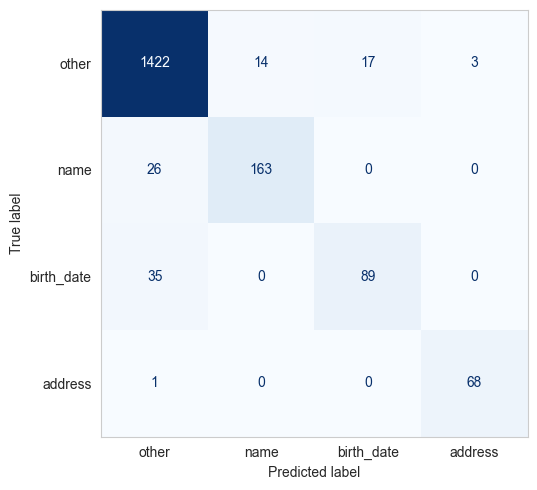

In [92]:
# Menggunakan variabel dari iterasi Fold terakhir
df_test_last = df_triage_test.copy()
df_seg_test_last = df_seg_test.copy()

avail_seg_feat = [f for f in FEATURE_COLS if f in df_seg_test_last.columns]
X_seg_last     = df_seg_test_last[avail_seg_feat].fillna(0)
y_true_last    = df_seg_test_last['label'].map(LABEL_MAP)
y_pred_last    = field_clf.predict(X_seg_last)

print("\nLaporan Akurasi Klasifikasi Teks Terakhir:")
print(classification_report(y_true_last, y_pred_last, target_names=['other','name','birth_date','address']))

fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_true_last, y_pred_last)
ConfusionMatrixDisplay(cm, display_labels=['other','name','birth_date','address']).plot(ax=ax, colorbar=False, cmap='Blues')
plt.grid(False)
plt.tight_layout()
plt.show()

## Mengukur Pentingnya Fitur dengan SHAP
Blok ini mencari tahu data numerik apa yang diprioritaskan oleh model Machine Learning untuk setiap prediksi kelas.
Kita memastikan bahwa keputusan yang diambil model sesuai dengan akal sehat dan tidak terpaku pada angka angka secara kebetulan belaka.

In [93]:
df_seg_test_last['pred_label_str'] = [INV_LABEL_MAP[p] for p in y_pred_last]

explainer   = shap.TreeExplainer(field_clf)
shap_values = explainer.shap_values(X_seg_last)

CLASS_NAMES = ['other', 'name', 'birth_date', 'address']
for class_idx, class_name in enumerate(CLASS_NAMES):
    if class_name == 'other':
        continue
    plt.figure(figsize=(10, 5))
    sv = shap_values[class_idx]
    if len(sv.shape) == 2 and sv.shape[1] == X_seg_last.shape[1] + 1:
        sv = sv[:, :-1]
        
    shap.summary_plot(
        sv,
        X_seg_last,
        feature_names=avail_seg_feat,
        show=False,
        plot_type='bar',
    )
    plt.title(f"Bobot Fitur Klasifikasi: {class_name.upper()}", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(DATASET_DIR, f'shap_{class_name}.png'), dpi=100)
    plt.show()

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1000x500 with 0 Axes>

## Menggambar Ulang Garis Pemotongan
Blok ini menampilkan ilustrasi KTP beserta hasil bacaan klasifikasinya yang digambar kotak warna warni di sekeliling teks.
Kita butuh meninjau kembali gambar ini agar tidak hanya berasumsi berdasar angka tabel tapi bisa melihat apakah titik lokasinya sudah akurat secara visual.

In [ ]:
import ast
VIS_OUT_DIR = os.path.join(DATASET_DIR, 'semantic_visualizations')
os.makedirs(VIS_OUT_DIR, exist_ok=True)

sample_files = list(df_test_last['filename'].head(5))

for fname in sample_files:
    img_path = os.path.join(CROPPED_DIR, fname)
    img      = cv2.imread(img_path)
    if img is None:
        continue

    segments = df_seg_test_last[df_seg_test_last['filename'] == fname]
    for _, seg in segments.iterrows():
        pred_str = seg['pred_label_str']
        if pred_str == 'other':
            continue

        try:
            box = ast.literal_eval(str(seg['box']))
        except:
            continue
        if not box:
            continue

        color = COLOR_MAP[pred_str]
        pts   = np.array(box, np.int32).reshape((-1, 1, 2))
        cv2.polylines(img, [pts], isClosed=True, color=color, thickness=2)

        x_min = int(np.min(pts[:, 0, 0]))
        y_min = int(np.min(pts[:, 0, 1]))
        cv2.putText(img, pred_str.upper(), (x_min, max(y_min - 5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 2)

    out_path = os.path.join(VIS_OUT_DIR, f"semantic_{fname}")
    cv2.imwrite(out_path, img)

    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## Menyimpan Laporan ke Dokumen
Blok ini menuliskan semua hasil angka akurasi ke dalam dokumen dan mencetak ulang ringkasan metrik secara ringkas di layar.
Kita wajib menyimpannya sebagai fail fisik supaya hasil eksekusi ini kelak bisa dibagikan dan tidak hilang saat aplikasi ditutup.

In [ ]:
all_metrics_df.to_csv(os.path.join(DATASET_DIR, 'evaluation_results.csv'), index=False)

print("Semua proses rampung.")
print(f"  evaluation_results.csv : {len(all_metrics_df)} rekam data")
print(f"  Metrik STP Rate Final  : {stp_rate:.1%}")